# Member 2 — Encoding Categorical Variables

**Technique:** Convert categorical fields (`label`, `region`, `folder`) into numeric codes ML models can consume.

## Why this dataset needs it
Folder names carry the **class** (Healthy / Unhealthy) and **region** (Amravati / Nagpur / Pune / Unknown). Models and correlation plots need integers or one-hot columns — not free text.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


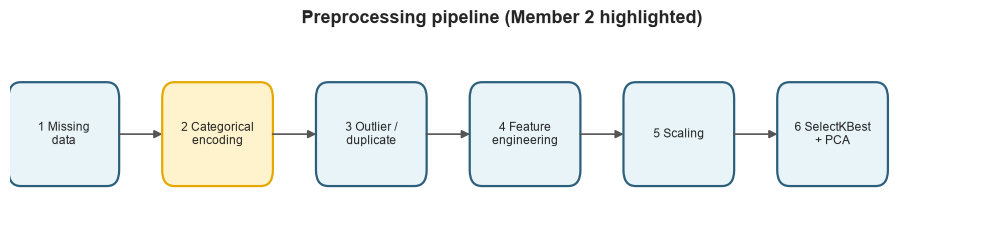

In [2]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 2 highlighted)",
    highlight=1,
)
fig.savefig(VIZ / "m2_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


## 1. Load audited index (or rebuild) and encode categories


In [3]:
index_path = OUT / "m1_valid_image_index.csv"
if index_path.exists():
    df = pd.read_csv(index_path)
    print("Loaded Member 1 valid index:", len(df))
else:
    df, rejected = audit_images(RAW)
    print("Audited fresh valid images:", len(df), "| rejected:", len(rejected))

# Label encoding (ordered class list for reproducibility)
label_map = {c: i for i, c in enumerate(CLASSES)}
df["label_encoded"] = df["label"].map(label_map).astype(int)

# Region encoding
regions = sorted(df["region"].dropna().unique().tolist())
region_map = {r: i for i, r in enumerate(regions)}
df["region_encoded"] = df["region"].map(region_map).astype(int)

# One-hot for region (useful for linear models / EDA)
region_dummies = pd.get_dummies(df["region"], prefix="region")
encoded = pd.concat([df, region_dummies], axis=1)

display(pd.DataFrame({"category": ["label", "region"], "mapping": [label_map, region_map]}))
display(encoded[["path", "label", "label_encoded", "region", "region_encoded"]].head(10))

encoded.to_csv(OUT / "m2_encoded_metadata.csv", index=False)
(LOGS / "m2_encoding_maps.json").write_text(
    json.dumps({"label_map": label_map, "region_map": region_map}, indent=2),
    encoding="utf-8",
)


Loaded Member 1 valid index: 1131


,category,mapping
0,label,"{'Healthy': 0, 'Unhealthy': 1}"
1,region,"{'Amravati': 0, 'Nagpur': 1, 'Pune': 2, 'Unkno..."


,path,label,label_encoded,region,region_encoded
0,Amravati_Region_Basil_Plant_Healthy/Good.jpeg,Healthy,0,Amravati,0
1,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
2,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
3,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
4,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
5,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
6,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
7,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
8,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0
9,Amravati_Region_Basil_Plant_Healthy/WhatsApp I...,Healthy,0,Amravati,0


152

## 2. EDA visualizations — encoded distributions & class × region comparison


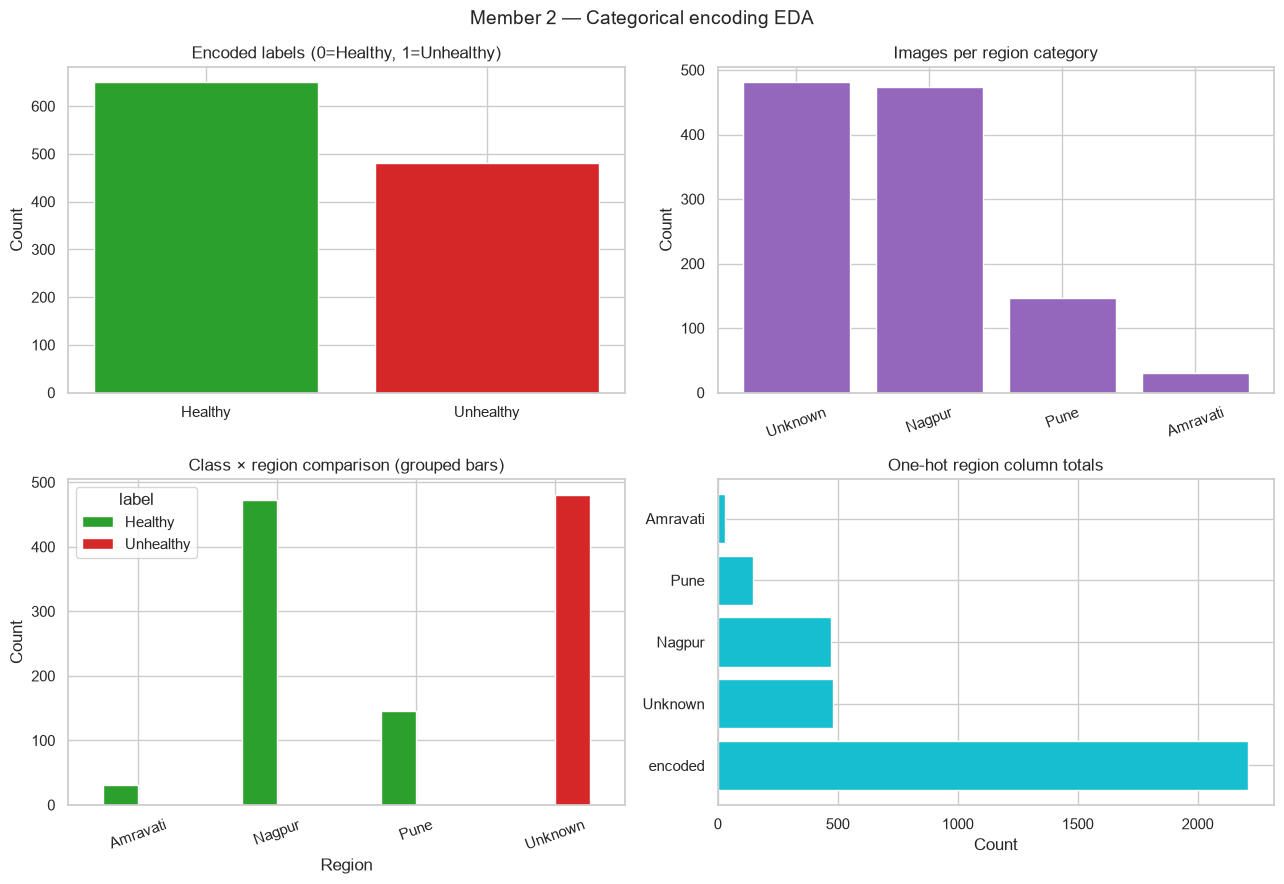

Interpretation: encoding preserves class/region structure while making columns numeric for downstream scaling and modelling.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Label codes
lc = encoded["label_encoded"].value_counts().sort_index()
axes[0, 0].bar([CLASSES[i] for i in lc.index], lc.values, color=["#2ca02c", "#d62728"])
axes[0, 0].set_title("Encoded labels (0=Healthy, 1=Unhealthy)")
axes[0, 0].set_ylabel("Count")

# Region codes
rc = encoded.groupby("region")["region_encoded"].count().sort_values(ascending=False)
axes[0, 1].bar(rc.index, rc.values, color="#9467bd")
axes[0, 1].set_title("Images per region category")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].set_ylabel("Count")

# Class × region stacked / grouped comparison
ct = pd.crosstab(encoded["region"], encoded["label"]).reindex(columns=CLASSES).fillna(0)
ct.plot(kind="bar", ax=axes[1, 0], color=["#2ca02c", "#d62728"], rot=20)
axes[1, 0].set_title("Class × region comparison (grouped bars)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xlabel("Region")

# One-hot column totals
oh_cols = [c for c in encoded.columns if c.startswith("region_")]
oh_sums = encoded[oh_cols].sum().sort_values(ascending=False)
axes[1, 1].barh([c.replace("region_", "") for c in oh_sums.index], oh_sums.values, color="#17becf")
axes[1, 1].set_title("One-hot region column totals")
axes[1, 1].set_xlabel("Count")

fig.suptitle("Member 2 — Categorical encoding EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m2_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: encoding preserves class/region structure while making columns numeric for downstream scaling and modelling.")
